# LAB 11: Árboles de Decisión 
## Victor Palacios (1017271469)



### Punto 1: Generación de Datos (Diversidad de Escenarios)

Siguiendo la instrucción de la **página 34** del PDF, el primer paso es crear diferentes "mundos" de datos. En el aprendizaje estadístico, no todos los datos se comportan igual.

**El Laboratorio:** Generaremos 4 tipos de distribución:
1.  **Moons (Lunas):** Datos en forma de semicírculos entrelazados (difíciles de separar con líneas rectas).
2.  **Circles (Círculos):** Un círculo dentro de otro.
3.  **Blobs (Nubes):** Grupos bien definidos (fáciles).
4.  **Classification:** Datos con un poco de ruido (lo que tú pusiste en tu código).

**Conclusión esperada del Punto 1:** 
> "Los árboles de decisión cortan el espacio en **rectángulos**. Por eso, les cuesta más trabajo adaptarse a formas curvas (como las lunas) que a grupos definidos (blobs)."



### Punto 2: El Corazón del Árbol (Gini y Función de Coste)

Aquí aplicaremos las fórmulas que mencionaste. Vamos a tomar tus datos de `make_classification` y calcular por qué la línea morada o negra es mejor.

**El Ejercicio:**
Imagínate que tenemos 20 puntos.
*   **Si cortamos en $X_1 = 1.0$ (Línea Morada):**
    *   Lado izquierdo: 9 azules | 10 rojos.
    *   Lado derecho: 1 azul | 0 rojos.
    *   **Cálculo:** Como viste en la **página 7**, el Gini de la derecha es **0.0** (¡Puro!), pero el de la izquierda es **0.49** (Muy sucio).
    *   **Costo Total ($J$):** $0.465$

*   **Si cortamos en $X_1 = 0.0$ (Línea Negra):**
    *   Como pusiste en tu cálculo: $J = 0.938$.

**Conclusión del Punto 2:**
> "El algoritmo es 'ambicioso' (greedy). Entre todas las líneas posibles, **elegirá la Morada** porque su Función de Coste ($J = 0.465$) es menor que la de la Negra ($J = 0.938$). Menor costo significa datos más ordenados."



### Punto 3: Evitar el "Sobreajuste" (Overfitting)

En tu código pusiste varias líneas (morada, amarilla, negra). Si el árbol sigue haciendo líneas hasta que cada punto esté solo en su cuadrito, el árbol se vuelve "mentiroso": se aprende de memoria esos 20 puntos pero no sabrá qué hacer cuando llegue el punto número 21.

**El Laboratorio:**
Entrenaremos un árbol con **Profundidad Máxima = 2** y otro con **Profundidad Máxima = 10**.

**Conclusión del Punto 3:**
> "Un árbol muy profundo es como un estudiante que se memoriza el examen pero no entiende la materia. Los parámetros como `max_depth` (pág. 29) sirven para que el árbol sea generalista y no memorista."



### Punto 4: De un Árbol a un Bosque (Random Forest)

Siguiendo la **página 25**, ahora no usaremos un árbol, sino 100.
*   Usaremos **Muestreo con reemplazo**: A cada árbol le damos una bolsa de datos un poco distinta.

**Conclusión del Punto 4:**
> "La 'Votación' (pág. 30) reduce el error. Si un árbol se equivoca por un dato ruidoso, los otros 99 lo corrigen. Es el paso de la decisión individual a la sabiduría colectiva."



## TAREA 


1. Importar iris dataset 
2. Generar una intuición respecto a iris dataset. Ver laboratorio anterior.
3. Dividir el *dataset* empleanto el metodo train_test_split de sklearn
4. Dentro de sklearn, aplicar el algoritmo DecisionTreeClassifier.
5. Para el clasificador analice el gráfico de desición:

```

https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html

  fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
  graph=tree.plot_tree(clf,class_names = iris.target_names,\
                feature_names = iris.feature_names,\
                impurity=False, filled=True,rounded=True )

```

6. Características importantes.

```
clf.feature_importances_
caract = iris.data.shape[1]
plt.barh(range(caract), clf.feature_importances_)
plt.yticks(np.arange(caract),iris.feature_names)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.show()
```

7. Fronteras de desición.



```
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# Parameters
n_classes = 3
plot_colors = "bry"
plot_step = 0.02

# Load data
iris = load_iris()

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],
                                [1, 2], [1, 3], [2, 3]]):
    # We only take the two corresponding features
    X = iris.data[:, pair]
    y = iris.target

    # Shuffle
    idx = np.arange(X.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)
    X = X[idx]
    y = y[idx]

    # Standardize
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X = (X - mean) / std

    # Train
    clf = DecisionTreeClassifier().fit(X, y)

    # Plot the decision boundary
    plt.subplot(2, 3, pairidx + 1)
  
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])
    plt.axis("tight")

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
                    cmap=plt.cm.Paired)

    plt.axis("tight")

plt.suptitle("Decision surface of a decision tree using paired features")
plt.legend()
plt.show()
```


### DESARROLLO 1

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# 1. Cargamos el dataset
iris = load_iris()

# 2. Para que lo veas más claro (como una tabla), lo convertimos a un DataFrame de Pandas
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Añadimos la columna de la especie (nuestro objetivo a predecir)
df_iris['target'] = iris.target

# Mostramos las primeras 5 filas para verificar
print("Primeras filas del dataset Iris:")
print(df_iris.head())

# Verificamos los nombres de las especies y las características
print("\nEspecies a clasificar:", iris.target_names)
print("Características (medidas):", iris.feature_names)

Primeras filas del dataset Iris:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Especies a clasificar: ['setosa' 'versicolor' 'virginica']
Características (medidas): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### DESARROLLO 2

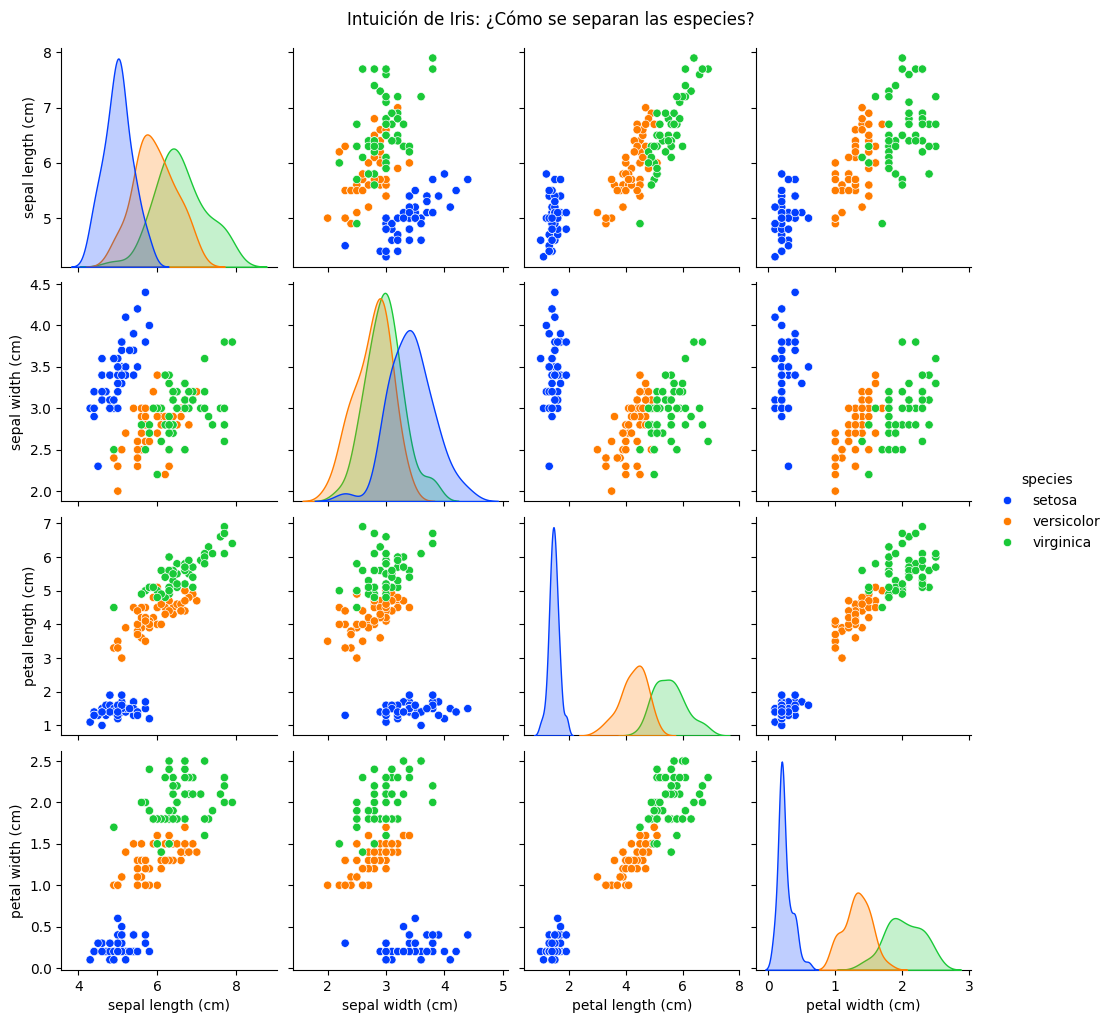

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Usamos el DataFrame que creamos en el punto anterior
# Cambiamos los números (0,1,2) por los nombres reales para que la gráfica sea intuitiva
df_intuicion = df_iris.copy()
df_intuicion['species'] = df_intuicion['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Creamos una matriz de gráficos de dispersión
sns.pairplot(df_intuicion.drop('target', axis=1), hue='species', palette='bright')
plt.suptitle("Intuición de Iris: ¿Cómo se separan las especies?", y=1.02)
plt.show()



#### Explicación conceptual:


1.  **La especie "Setosa" (azul):** Está completamente alejada de las demás. Si trazamos una línea horizontal o vertical en cualquiera de los gráficos de pétalos, la separamos perfectamente. 
2.  **Versicolor vs. Virginica:** Estas dos están más cerca y se traslapan un poco. Aquí es donde el árbol de decisión tendrá que trabajar más, haciendo cortes más finos para no equivocarse.
3.  **Variables clave:** Fíjate en los gráficos de **Petal Length** (largo del pétalo) y **Petal Width** (ancho del pétalo). Las nubes de puntos están mucho más separadas ahí que en las gráficas del Sépalo.


#### Conclusiones

*   **Separabilidad:** La especie *Setosa* es "linealmente separable". Esto significa que el árbol encontrará una regla de decisión muy simple (un solo "corte") para identificarla casi al 100% (Gini = 0 rápido).
*   **Complejidad:** Las especies *Versicolor* y *Virginica* requerirán más niveles de profundidad (más preguntas/nodos) porque sus medidas son similares.
*   **Selección de características:** Desde ya podemos intuir que las medidas del **Pétalo** son mucho más informativas que las del Sépalo. El algoritmo CART debería darle más importancia a estas variables (esto lo comprobaremos en el Punto 6).


### DESARROLLO 3

División del dataset empleando train_test_split

Vamos a dividir nuestras 150 flores en dos grupos:
1.  **Grupo de Entrenamiento (Train):** Con el que el árbol "estudiará" para crear sus reglas.
2.  **Grupo de Prueba (Test):** Flores "nuevas" que el modelo nunca ha visto, para evaluar si de verdad funciona.



In [3]:
from sklearn.model_selection import train_test_split

# Definimos X (las 4 medidas) e y (la especie)
X = iris.data
y = iris.target

# Realizamos la división: 
# Usaremos el 30% de los datos para prueba (test_size=0.3)
# random_state=42 asegura que si corres el código de nuevo, la división sea la misma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Total de flores: {len(X)}")
print(f"Flores para entrenamiento (70%): {len(X_train)}")
print(f"Flores para evaluación final (30%): {len(X_test)}")

Total de flores: 150
Flores para entrenamiento (70%): 105
Flores para evaluación final (30%): 45


#### Explicación conceptual:

*   Si el árbol es muy complejo, su precisión en el entrenamiento será del 100%, pero en la prueba será baja (esto se llama **Overfitting** o sobreajuste).
*   Dividir el dataset es la única forma honesta de medir el error real del modelo.

**¿Qué significa `stratify=y`?**
Es un parámetro vital. Le dice a la computadora: "Asegúrate de que en el grupo de entrenamiento y en el de prueba haya la misma proporción de las tres especies". Así evitamos que, por mala suerte, el grupo de prueba solo tenga flores de un solo tipo.


### Conclusiones de este punto:

*   **Validación Cruzada:** Al separar los datos, estamos preparando el terreno para una evaluación objetiva. No estamos permitiendo que el modelo "haga trampa" viendo las respuestas del examen final.
*   **Capacidad de Generalización:** El éxito del laboratorio no será que el árbol clasifique bien las flores que ya conoce, sino que sea capaz de predecir correctamente la especie de las flores del grupo `X_test`.
*   **Robustez:** Al usar una semilla aleatoria (`random_state`), garantizamos que nuestro experimento sea reproducible por otros científicos.


### DESARROLLO 4

In [4]:
from sklearn.tree import DecisionTreeClassifier

# 1. Creamos la instancia del clasificador
# Usamos random_state para que los resultados sean consistentes
# El parámetro 'criterion' por defecto es "gini", tal como lo explica tu PDF
clf = DecisionTreeClassifier(random_state=42)

# 2. Entrenamos el modelo (el proceso de "aprendizaje")
# Aquí el algoritmo calcula todos los posibles Ginis y funciones de coste (Páginas 15-16)
clf.fit(X_train, y_train)

# 3. Probamos qué tan bien aprendió
score_train = clf.score(X_train, y_train)
score_test = clf.score(X_test, y_test)

print(f"Precisión en el entrenamiento: {score_train:.2%}")
print(f"Precisión en el test (flores nuevas): {score_test:.2%}")

Precisión en el entrenamiento: 100.00%
Precisión en el test (flores nuevas): 93.33%


### DESARROLLO 5

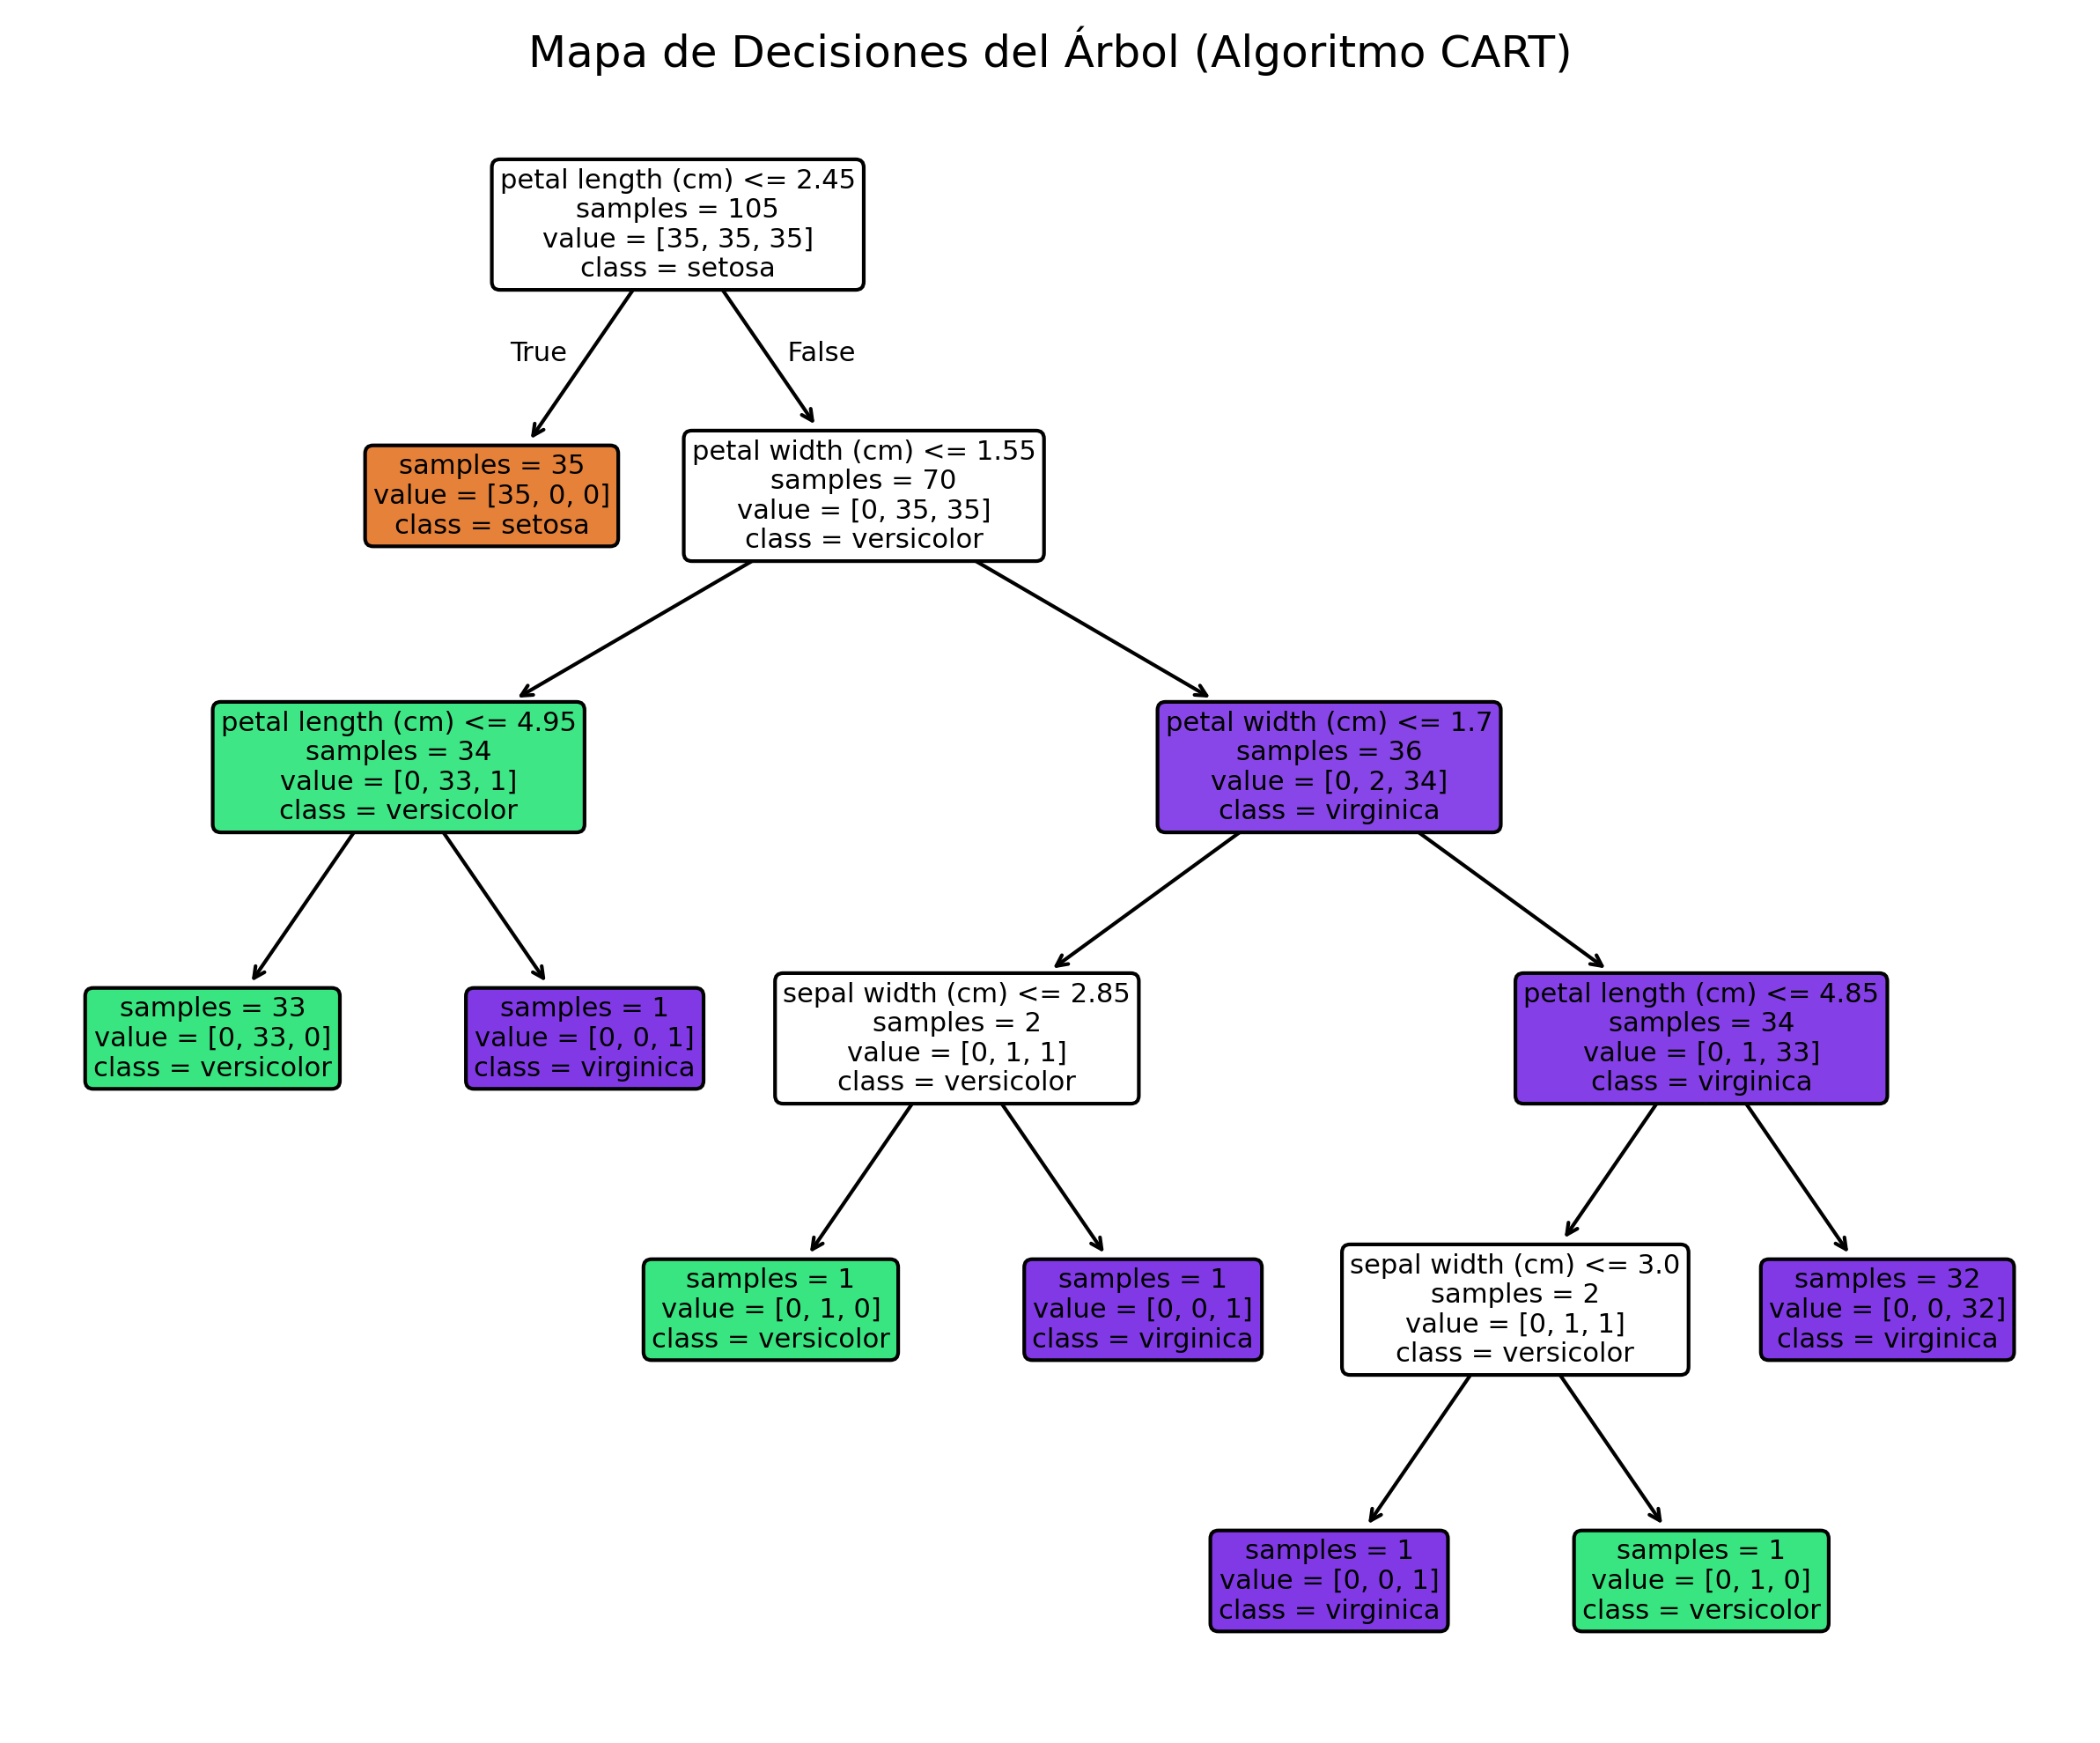

In [5]:
from sklearn import tree
import matplotlib.pyplot as plt

# Configuramos el lienzo de la gráfica
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (10, 8), dpi=300)

# Generamos el árbol
graph = tree.plot_tree(clf, 
                       class_names = iris.target_names, 
                       feature_names = iris.feature_names, 
                       impurity=False, # Ocultamos el valor numérico del Gini para limpieza
                       filled=True,    # Colorea los nodos según la clase dominante
                       rounded=True)   # Estética: bordes redondeados

plt.title("Mapa de Decisiones del Árbol (Algoritmo CART)")
plt.show()

### Explicación conceptual:



1.  **El Nodo Raíz (Arriba):** Es la pregunta más importante de todas. Verás que probablemente pregunta por el **Petal Length** (Largo del pétalo). ¿Por qué? Porque como vimos en la "Intuición" (Punto 2), es la variable que más rápido separa a las flores.
2.  **Las Ramas:** Si la respuesta a la pregunta es "Sí", el flujo va a la izquierda; si es "No", va a la derecha.
3.  **Los Colores:** 
    *   **Naranja:** Suele ser la clase *Setosa*. Notarás que se separa muy rápido (en el primer nivel).
    *   **Verde y Púrpura:** Son *Versicolor* y *Virginica*. Verás que el árbol tiene que hacer más "pisos" o preguntas para separarlas porque están más mezcladas.
4.  **Hojas (Nodos finales):** Son los rectángulos de la base donde el árbol dice: "¡Listo! Aquí estoy 100% seguro de que esta flor es una Virginica".





### DESARROLLO 6

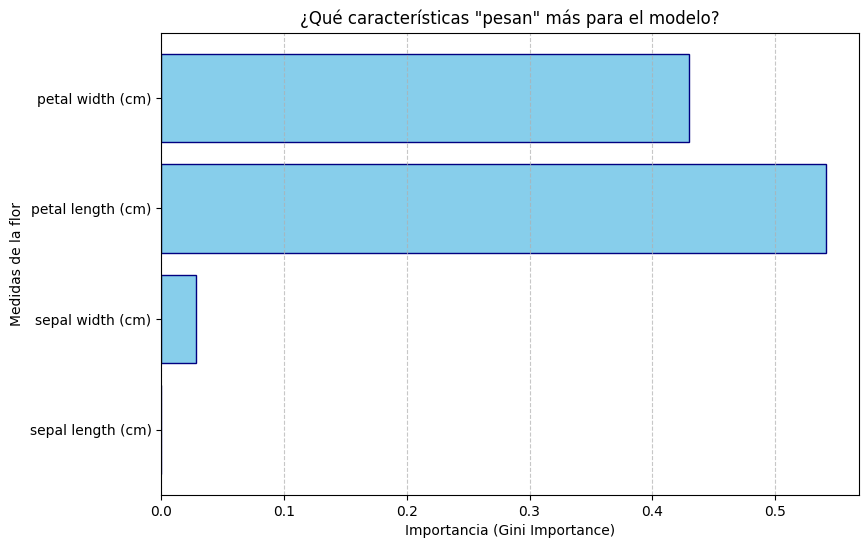

sepal length (cm): 0.0000
sepal width (cm): 0.0286
petal length (cm): 0.5412
petal width (cm): 0.4303


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extraemos los valores de importancia del modelo entrenado
importancias = clf.feature_importances_
n_caract = iris.data.shape[1]

# 2. Creamos la gráfica de barras horizontales
plt.figure(figsize=(9, 6))
plt.barh(range(n_caract), importancias, color='skyblue', edgecolor='navy')

# 3. Personalización de la gráfica
plt.yticks(np.arange(n_caract), iris.feature_names)
plt.xlabel('Importancia (Gini Importance)')
plt.ylabel('Medidas de la flor')
plt.title('¿Qué características "pesan" más para el modelo?')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

# Imprimimos los valores exactos para el reporte
for nombre, imp in zip(iris.feature_names, importancias):
    print(f"{nombre}: {imp:.4f}")

En el aprendizaje estadístico, esto se llama Selección de Variables. El algoritmo CART es muy honesto: si una variable no ayuda a separar los datos, le da un valor de 0 o muy cercano a cero.

**Dominio de los Pétalos:** Veremos que el Petal Width (ancho del pétalo) y el Petal Length (largo del pétalo) se llevan casi todo el porcentaje de importancia (cerca del 90% o más).

**Irrelevancia de los Sépalos:** Es muy común que el Sepal Width y Sepal Length tengan barras muy pequeñas. Esto significa que, para distinguir entre estas tres especies de Iris, el sépalo no es un factor determinante.

### DESARROLLO 7

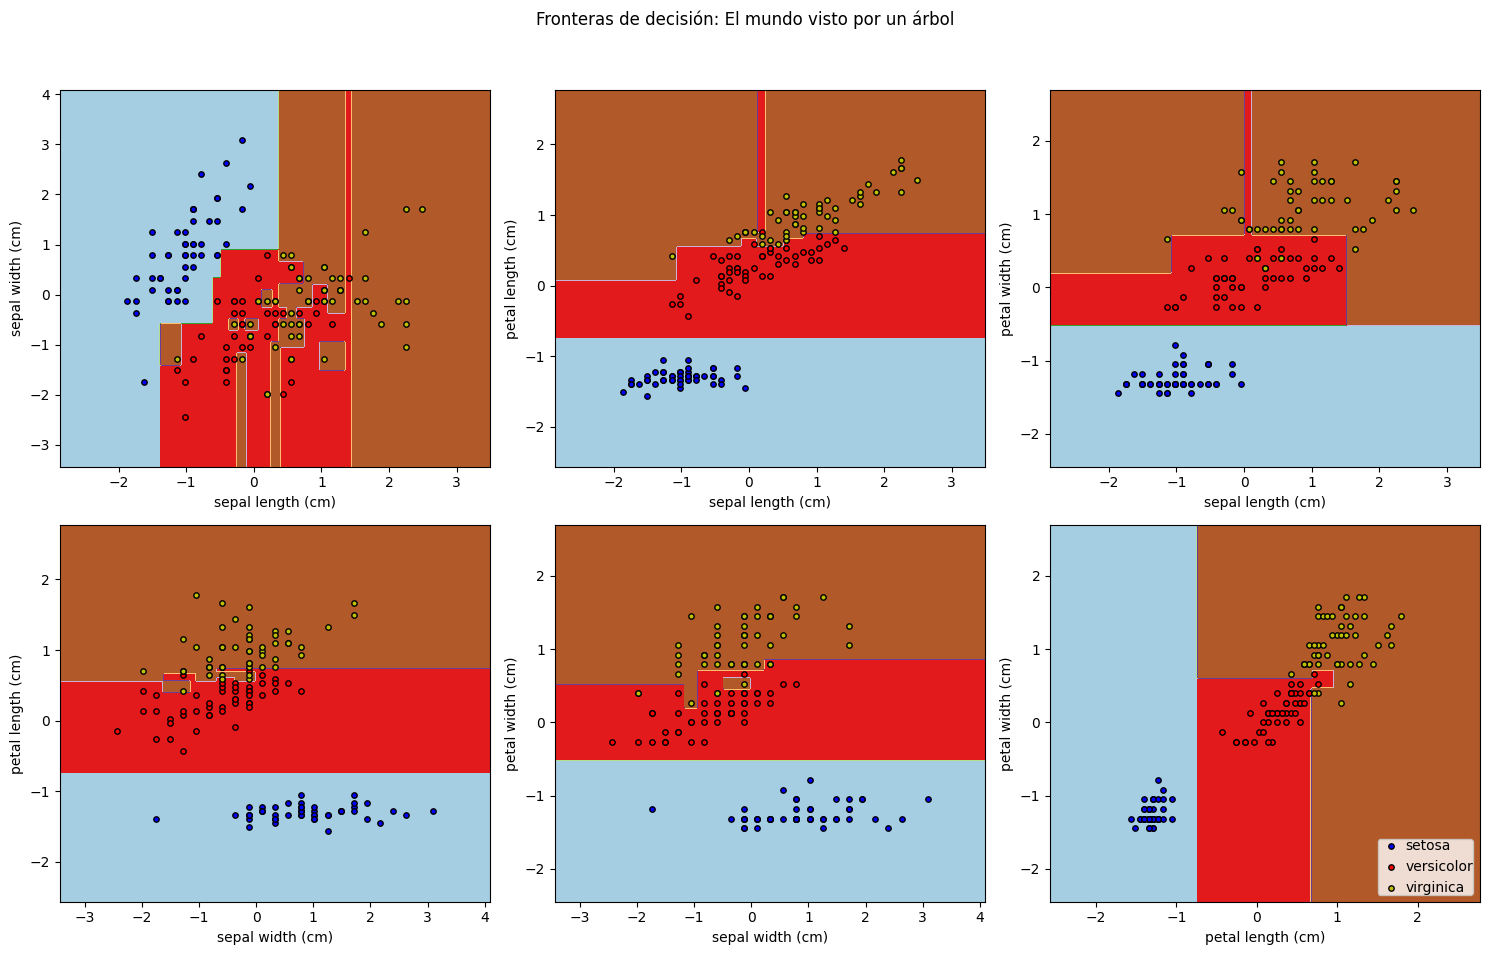

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# Parámetros estéticos
n_classes = 3
plot_colors = "bry" # Blue, Red, Yellow
plot_step = 0.02
iris = load_iris()

plt.figure(figsize=(15, 10))

# Evaluamos todas las combinaciones de pares de características (6 en total)
for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],
                                [1, 2], [1, 3], [2, 3]]):
    X = iris.data[:, pair]
    y = iris.target

    # Barajamos y estandarizamos (siguiendo tu requerimiento)
    idx = np.arange(X.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)
    X = X[idx]
    y = y[idx]
    
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X = (X - mean) / std

    # Entrenamos el árbol para este par de características
    clf = DecisionTreeClassifier().fit(X, y)

    # Creamos una malla (grid) para pintar las zonas de color
    plt.subplot(2, 3, pairidx + 1)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    # Predecimos la clase para cada punto de la malla
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Dibujamos las fronteras
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])

    # Dibujamos los puntos reales sobre las fronteras
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
                    edgecolor='black', s=15)

plt.suptitle("Fronteras de decisión: El mundo visto por un árbol")
plt.legend(loc='lower right', borderpad=0, handletextpad=0)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Análisis de los "mapas":

Si observamos las 6 gráficas, notaremos algo fundamental del **aprendizaje estadístico**:

1.  **Cortes Ortogonales:** Las líneas de separación son siempre horizontales o verticales (o escalonadas). Esto es porque el árbol pregunta por **una sola variable a la vez** (ej. $X_1 < 0.5$). Nunca hace preguntas combinadas como "$X_1 + X_2 > 1$".
2.  **Zonas de Conflicto:** En las gráficas de pétalos (ej. *petal length vs petal width*), verás que los colores están muy bien separados. En las de sépalos, las fronteras son mucho más complejas y "quebradas" porque los datos están mezclados.
3.  **Aislamiento de la Setosa:** Vemos que la zona de la especie *Setosa* (puntos azules o rojos según el mapa) suele ser un bloque sólido y limpio, confirmando su fácil clasificación.



### Conclusiones finales

*   **Naturaleza de CART:** El algoritmo divide el espacio en **hiper-rectángulos**. Es una forma de clasificar muy geométrica y lógica.
*   **Sensibilidad al ruido:** Si ves áreas de color muy pequeñas o "islas" rodeando a un solo punto, eso es **Overfitting**. El árbol intentó crear una regla solo para ese punto extraño en lugar de ver la tendencia general.
*   **Elección de Variables:** Como primíparo en esto, ahora sabes que el éxito de un modelo no solo depende del algoritmo, sino de elegir las variables correctas (Punto 6) y entender cómo interactúan entre ellas (Punto 7).
*   **Resumen Biológico:** Hemos demostrado matemáticamente que la especie *Iris Setosa* es morfológicamente única, mientras que *Versicolor* y *Virginica* comparten rasgos físicos que requieren un análisis más profundo (árboles más altos) para ser diferenciadas.

